# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Matthias van Weeren
* Username: mbweeren
* Student number: s6457002
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

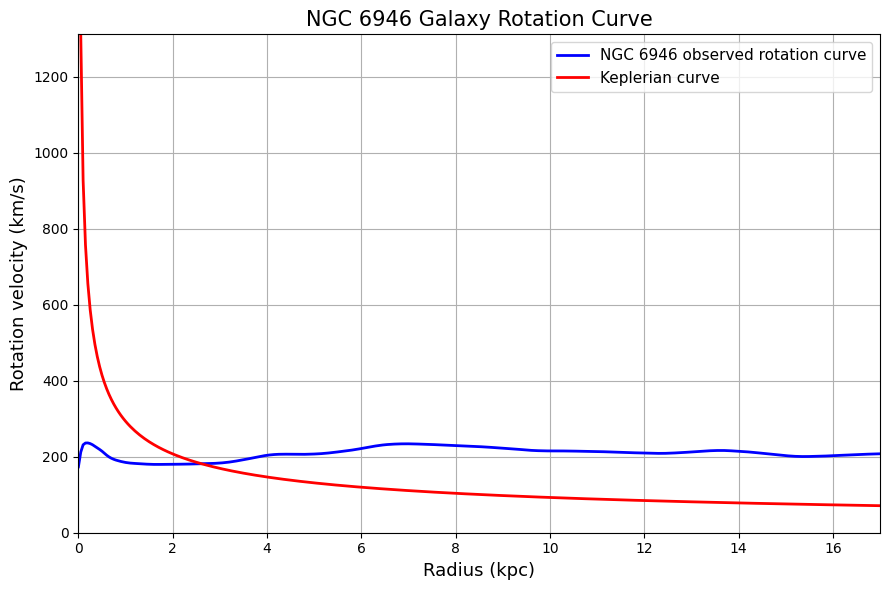

In [2]:
import numpy as np
from scipy.constants import G
import matplotlib.pyplot as plt

#Seperating columns of rotcur.dat:
data = np.loadtxt('/Users/users/mbweeren/PROGNUM-repo/Task5/rotcur.dat')
radius = data[:, 0]
v = data[:, 1]

#Defining variables:
M_sun = 1.989e30
M_star = 2e10 * M_sun

r = radius[1:] * 3.086e19
vkepms = np.sqrt(G * M_star / r)
vkep = vkepms / 1e3

rkep = radius[1:]

#Creating and saving textfile keplerian_curve.txt:
keplerian_curve = np.column_stack((rkep, vkep))
np.savetxt('keplerian_curve.txt', keplerian_curve)

#Loading data:
kep_data = np.loadtxt('keplerian_curve.txt')
r_kep_load = kep_data[:, 0]
v_kep_load = kep_data[:, 1]

plt.figure(figsize=(9, 6))

plt.plot(radius, v, color='blue', linewidth=2, label='NGC 6946 observed rotation curve')
plt.plot(r_kep_load, v_kep_load, color='red', linewidth=2, label='Keplerian curve')

#Setting the limits for the curves:
plt.ylim(0, v_kep_load.max())
plt.xlim(0, radius.max())

#Plotting curve:
plt.xlabel('Radius (kpc)', fontsize=13)
plt.ylabel('Rotation velocity (km/s)', fontsize=13)
plt.title('NGC 6946 Galaxy Rotation Curve', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True)

plt.tight_layout()
plt.savefig('rotation_curve.png')
plt.show()

We can deduce from these graphs that the observed roation curve is not very similar to the keplarian curve. From this we can conclude that there must be an additional mass, such as dark matter, somewhere in the galaxy, to account for the difference in oberved versus expected rotation speed of the outer orbiting stars.

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

The mean of the pixel values in the slice is: -0.003496975720266691
The standard deviation of the pixel values in the slice is:  1.008712831492813


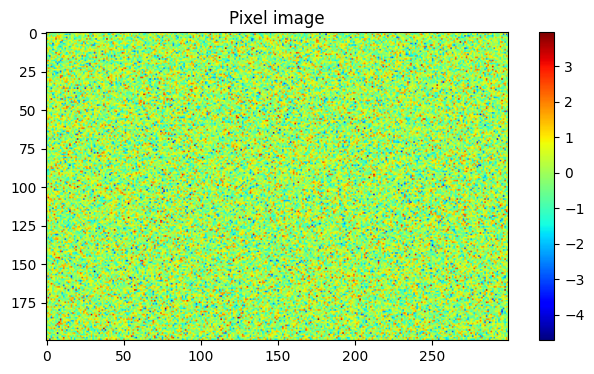

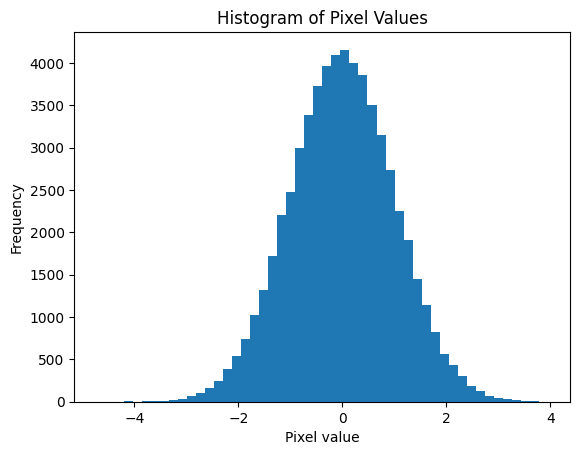

In [4]:
import numpy as np
from matplotlib import pyplot as plt

image = np.random.normal(0, 1, (200, 300))

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(image, cmap='jet')
fig.colorbar(im, ax=ax)
ax.set_title('Pixel image')

#Slicing
twoD_slice = image[50:80, 100:130]
slice_mean = np.mean(twoD_slice)
slice_std = np.std(twoD_slice)

#Retun mean and std:
print(f"The mean of the pixel values in the slice is: {slice_mean}")
print(f"The standard deviation of the pixel values in the slice is:  {slice_std}")

#Plotting histogram
fig2, ax2 = plt.subplots()
ax2.hist(image.ravel(), bins=50)
ax2.set_title('Histogram of Pixel Values')
ax2.set_xlabel('Pixel value')
ax2.set_ylabel('Frequency')
plt.show()

Since we coded that the mean of the random normal dsitrubution to be 0 and its standard deviation to be 1.0, the outputted mean and standard deviation indeed roughly have the expected values.
The distribution I recognize is a normal distribution, which thus has a mean of ~0 and a standard deviation of ~1.0.

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Example of an ellipse: AstroEllipse(center=(0, 0), semi_major=3, semi_minor=2, angle=45)
The area of the ellipse is: 18.84955592153876
The Perimeter of the ellipse is: 15.865439589251233


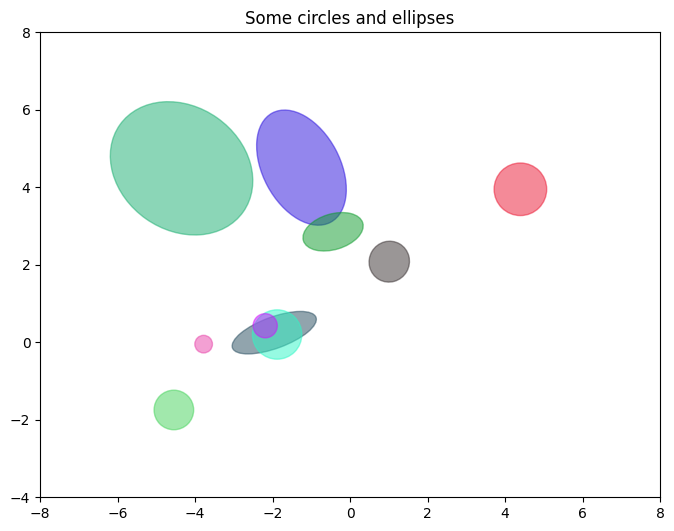

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse

#Copied code
class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)
    
    #Letting the arguments of the previous function be variables:
      self.xc = xc
      self.yc = yc
      self.semi_major = semi_major
      self.semi_minor = semi_minor
      self.position_angle = position_angle

    #Function calculating the area of the ellipse:
    def area(self):
        return np.pi * self.semi_major * self.semi_minor
    
    #Function calculating the perimiter of the ellipse:
    def perimeter(self):
        a = self.semi_major
        b = self.semi_minor
        h = ((a - b) ** 2) / ((a + b) ** 2)
        return np.pi * (a + b) * (1 + (3*h)/(10 + np.sqrt(4 - 3*h)))
    #Method _str_:
    def __str__(self):
        return (f"AstroEllipse(center=({self.xc}, {self.yc}), "
                f"semi_major={self.semi_major}, semi_minor={self.semi_minor}, "
                f"angle={self.position_angle})")

#Creating class MyCircle
class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, semi_major=radius, semi_minor=radius, 
                         position_angle=0, **args)

ellipse = AstroEllipse(0, 0, 3, 2, 45)
print("Example of an ellipse:", ellipse)
print(f"The area of the ellipse is: {ellipse.area()}")
print(f"The Perimeter of the ellipse is: {ellipse.perimeter()}")

#Creating plot:
fig, ax = plt.subplots(figsize=(8, 8))

np.random.seed(42)
n_ellipses = 5
n_circles  = 5

for _ in range(n_ellipses):
    xc    = np.random.uniform(-5, 5)
    yc    = np.random.uniform(-5, 5)
    smaj  = np.random.uniform(0.5, 2.0)
    smin  = np.random.uniform(0.1, smaj) 
    angle = np.random.uniform(0, 180)
    color = np.random.rand(3)
    ell = AstroEllipse(xc, yc, smaj, smin, angle,
                       color=color, alpha=0.5)
    ax.add_patch(ell)

for _ in range(n_circles):
    xc     = np.random.uniform(-5, 5)
    yc     = np.random.uniform(-5, 5)
    radius = np.random.uniform(0.2, 1.0)
    color  = np.random.rand(3)
    circ = MyCircle(xc, yc, radius, color=color, alpha=0.5)
    ax.add_patch(circ)

ax.set_xlim(-8, 8)
ax.set_ylim(-4, 8)
ax.set_aspect('equal')
ax.set_title("Some circles and ellipses")
plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

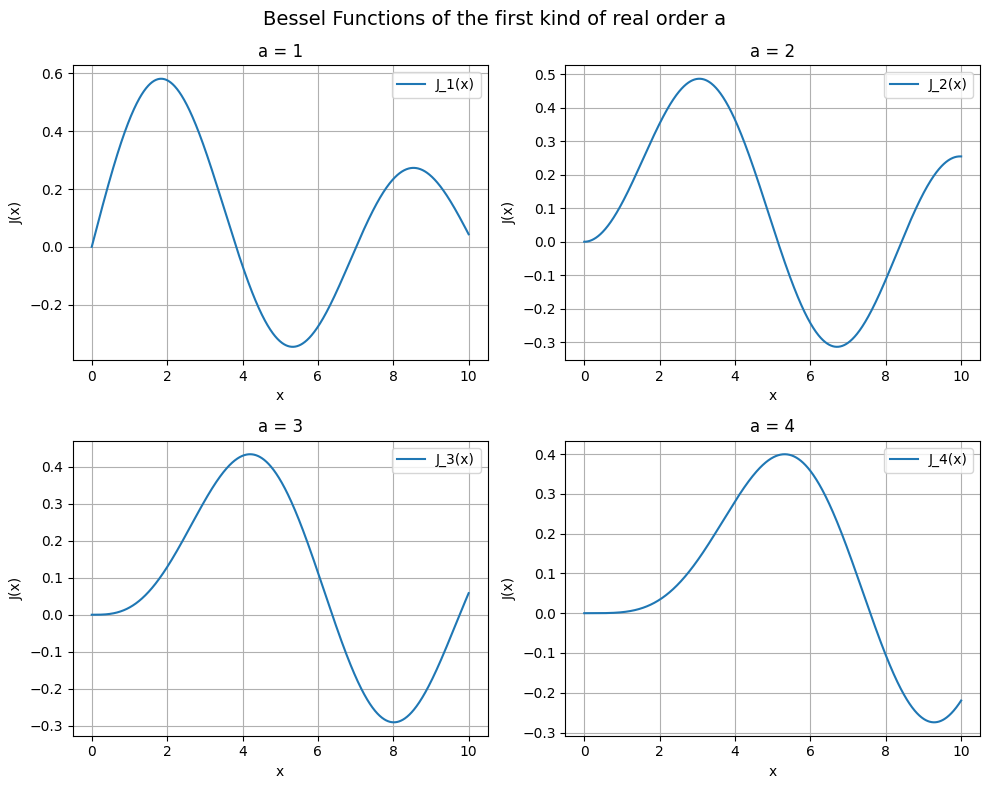

In [8]:
from scipy.special import jv
import numpy as np
from matplotlib import pyplot as plt

x = np.linspace(0, 10, 1000)
a_values = [1, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Bessel Functions of the first kind of real order a", fontsize=14)

for ax, a in zip(axes.flatten(), a_values):
    ax.plot(x, jv(a, x), label=f'J_{a}(x)')
    ax.set_title(f'a = {a}')
    ax.set_xlabel('x')
    ax.set_ylabel('J(x)')
    ax.legend()
    ax.grid(True)
    
#Plotting and saving figure:
plt.tight_layout()
plt.savefig('bessel.png', transparent=True)
plt.show()

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

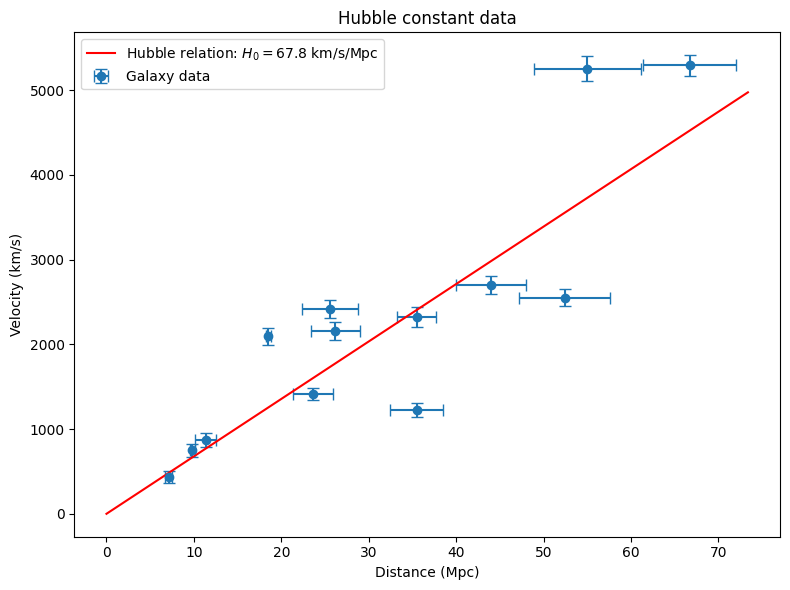

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = [
    [18.49, 2094.75, 0.3, 100],
    [35.48, 2320.87, 2.2, 120],
    [35.48, 1224.9,  3.0, 80],
    [11.34, 872.13,  1.2, 80],
    [7.12,  432.2,   0.4, 70],
    [9.82,  751,     0.3, 75],
    [23.66, 1410,    2.3, 70],
    [44,    2700,    4.0, 110],
    [66.7,  5292,    5.3, 120],
    [52.4,  2550,    5.2, 100],
    [55,    5253,    6.1, 150],
    [25.6,  2419,    3.2, 110],
    [26.19, 2158,    2.8, 110]
]

#Unpacking data columns
data = np.array(data)
d = data[:, 0]
v = data[:, 1]
error_d = data[:, 2]
error_v = data[:, 3]

H0 = 67.8

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(d, v, xerr=error_d, yerr=error_v, fmt='o', label='Galaxy data', capsize=4)

d_line = np.linspace(0, max(d) * 1.1, 100)
ax.plot(d_line, H0 * d_line, color='red', label=r'Hubble relation: $H_0 = 67.8$ km/s/Mpc')

ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Velocity (km/s)')
ax.set_title('Hubble constant data')
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
